<a href="https://colab.research.google.com/github/timfan705/CoderGym/blob/main/cmpe188_hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# Pipelines:
#  1. TF-IDF + Naive Bayes
#  2. TF-IDF + SVM
#  3. Word2Vec + Neural Network

# Code Section

In [15]:
!pip install gensim

In [16]:
# standard imports used to reading data, fast numerical operations in sklearn, managing runtime / warnings
import pandas as pd
import numpy as np
import time
import warnings
import re

# Visualization librarys to plot data (graphs, charts), statistical plots
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# importng scikit-learn (classic ML)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Used for the Naive Bayes classifier
from sklearn.naive_bayes import MultinomialNB

# Used for SVM
from sklearn.svm import LinearSVC

# Used for converting labels into numbers
from sklearn.preprocessing import LabelEncoder

# The evaluation metrics to measure performance of each model
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)

# Imports the modules for deeplearning and building neural network (used for 3rd pipeline of word2vec + NN)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from gensim.models import Word2Vec

warnings.filterwarnings("ignore")

In [17]:
# loading and processing data
def preprocess_text(text):
    """
    Basic text cleaner:
    - Lowercase
    - Remove non-alphanumeric characters (keep spaces)
    - Strip extra whitespace
    """
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("LOADING AND PREPROCESSING DATA")

df = pd.read_csv("/content/train_with_task_type.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['task_type'].value_counts()}")

# apply the text cleaning function we made
df["clean_prompt"] = df["prompt"].apply(preprocess_text)

# Encode labels
le = LabelEncoder()
df["label"] = le.fit_transform(df["task_type"])
class_names = le.classes_
num_classes = len(class_names)
print(f"\nClasses ({num_classes}): {list(class_names)}")

# Train/test split (80/20, stratified)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_prompt"], df["label"],
    test_size=0.2, random_state=42, stratify=df["label"]
)

print(f"\nTrain size: {len(X_train_text)} | Test size: {len(X_test_text)}")


LOADING AND PREPROCESSING DATA
Dataset shape: (9500, 7)

Class distribution:
task_type
bit_manipulation    1602
gravity             1597
unit_conversion     1594
cipher_text         1576
roman               1576
symbol_transform    1555
Name: count, dtype: int64

Classes (6): ['bit_manipulation', 'cipher_text', 'gravity', 'roman', 'symbol_transform', 'unit_conversion']

Train size: 7600 | Test size: 1900


In [18]:
# First Pipeline --> TF-IDF + Naive Bayes

# feature extraction
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# training the model using multinomial naive bayes -> used commonly for text-classification
nb_model = MultinomialNB(alpha=0.1)
t0 = time.time()
nb_model.fit(X_train_tfidf, y_train)
nb_train_time = time.time() - t0
print(f"Training time: {nb_train_time:.4f}s")

t0 = time.time()
nb_preds = nb_model.predict(X_test_tfidf)
nb_infer_time = time.time() - t0
print(f"Inference time: {nb_infer_time:.4f}s")

# metrics for measuring accuracy, f1-score, precision, and recall
nb_acc  = accuracy_score(y_test, nb_preds)
nb_f1   = f1_score(y_test, nb_preds, average="weighted")
nb_prec = precision_score(y_test, nb_preds, average="weighted")
nb_rec  = recall_score(y_test, nb_preds, average="weighted")
nb_cm   = confusion_matrix(y_test, nb_preds)

print(f"Accuracy:  {nb_acc:.4f}")
print(f"F1:        {nb_f1:.4f}")
print(f"Precision: {nb_prec:.4f}")
print(f"Recall:    {nb_rec:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, nb_preds, target_names=class_names))


Training time: 0.0164s
Inference time: 0.0026s
Accuracy:  1.0000
F1:        1.0000
Precision: 1.0000
Recall:    1.0000

Detailed Report:
                  precision    recall  f1-score   support

bit_manipulation       1.00      1.00      1.00       320
     cipher_text       1.00      1.00      1.00       315
         gravity       1.00      1.00      1.00       320
           roman       1.00      1.00      1.00       315
symbol_transform       1.00      1.00      1.00       311
 unit_conversion       1.00      1.00      1.00       319

        accuracy                           1.00      1900
       macro avg       1.00      1.00      1.00      1900
    weighted avg       1.00      1.00      1.00      1900



In [19]:
# Second Pipeline --> TF-IDF + SVM

# using the same TF-IDF features from the previous model in naive bayes
svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)

# training SVM model
t0 = time.time()
svm_model.fit(X_train_tfidf, y_train)
svm_train_time = time.time() - t0
print(f"Training time: {svm_train_time:.4f}s")

t0 = time.time()
svm_preds = svm_model.predict(X_test_tfidf)
svm_infer_time = time.time() - t0
print(f"Inference time: {svm_infer_time:.4f}s")

# metrics for SVM
svm_acc  = accuracy_score(y_test, svm_preds)
svm_f1   = f1_score(y_test, svm_preds, average="weighted")
svm_prec = precision_score(y_test, svm_preds, average="weighted")
svm_rec  = recall_score(y_test, svm_preds, average="weighted")
svm_cm   = confusion_matrix(y_test, svm_preds)

print(f"Accuracy:  {svm_acc:.4f}")
print(f"F1:        {svm_f1:.4f}")
print(f"Precision: {svm_prec:.4f}")
print(f"Recall:    {svm_rec:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, svm_preds, target_names=class_names))

Training time: 0.4200s
Inference time: 0.0037s
Accuracy:  1.0000
F1:        1.0000
Precision: 1.0000
Recall:    1.0000

Detailed Report:
                  precision    recall  f1-score   support

bit_manipulation       1.00      1.00      1.00       320
     cipher_text       1.00      1.00      1.00       315
         gravity       1.00      1.00      1.00       320
           roman       1.00      1.00      1.00       315
symbol_transform       1.00      1.00      1.00       311
 unit_conversion       1.00      1.00      1.00       319

        accuracy                           1.00      1900
       macro avg       1.00      1.00      1.00      1900
    weighted avg       1.00      1.00      1.00      1900



In [20]:
# Third Pipeline --> Word2Vec + Neural Networks

# Word2Vec: train on all text (train split only to avoid leakage)
# splits the sentence into words and stores in an array
tokenized_train = [t.split() for t in X_train_text]
tokenized_test  = [t.split() for t in X_test_text]

print("Training Word2Vec embeddings...")

# used to learn a 100-dimension vector for each word
w2v_model = Word2Vec(
    sentences=tokenized_train,
    # 100 numbers per word
    vector_size=100,
    # looks at 5 words around each word
    window=5,
    # ignores rare words
    min_count=2,
    workers=4,
    # passes over data 10 times
    epochs=10,
    seed=42
)

# takes all the word vectors in document and averages them
def get_doc_vector(tokens, model, size=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(size)
    return np.mean(vecs, axis=0)

# now that each is 1 vector of size 100, we can apply to dataset and train the shape
X_train_w2v = np.array([get_doc_vector(t, w2v_model) for t in tokenized_train])
X_test_w2v  = np.array([get_doc_vector(t, w2v_model) for t in tokenized_test])

print(f"Word2Vec feature matrix: train={X_train_w2v.shape}, test={X_test_w2v.shape}")

# creating the neural network definition
class TextClassifierNN(nn.Module):
    """
    Feed-forward neural network for text classification.
    Architecture: Input(100) -> FC(256) -> BN -> ReLU -> Dropout
                             -> FC(128) -> BN -> ReLU -> Dropout
                             -> FC(num_classes)
    """
    def __init__(self, input_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# converting to tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_tr = torch.tensor(X_train_w2v, dtype=torch.float32)
y_tr = torch.tensor(y_train.values, dtype=torch.long)
X_te = torch.tensor(X_test_w2v, dtype=torch.float32)
y_te = torch.tensor(y_test.values, dtype=torch.long)

train_dataset = TensorDataset(X_tr, y_tr)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

nn_model = TextClassifierNN(
    input_dim=100,
    hidden_dim=256,
    num_classes=num_classes
).to(device)

optimizer = torch.optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
criterion = nn.CrossEntropyLoss()

# training
EPOCHS = 20
print(f"Training Neural Network for {EPOCHS} epochs...")

t0 = time.time()
nn_model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for X_batch, y_batch in train_loader:
      # two loops, one for passes through the full dataset (epoch) and one to split dataset into chunks (batch)
        # first moves the data to the device (i believe on colab it would run on cpu)
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        # resetting the gradiants due to previous calculations and prior accumulations from PyTorch
        optimizer.zero_grad()
        # forward pass for output --> goes through each layer
        # input → prediction → loss → backward pass → update weights
        out  = nn_model(X_batch)
        # calculating loss using cross-entropy loss
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f}")

nn_train_time = time.time() - t0
print(f"Training time: {nn_train_time:.4f}s")

nn_model.eval()
t0 = time.time()
with torch.no_grad():
    logits   = nn_model(X_te.to(device))
    nn_preds = torch.argmax(logits, dim=1).cpu().numpy()
nn_infer_time = time.time() - t0
print(f"Inference time: {nn_infer_time:.4f}s")

# metrics for the neural network model:
nn_acc  = accuracy_score(y_test, nn_preds)
nn_f1   = f1_score(y_test, nn_preds, average="weighted")
nn_prec = precision_score(y_test, nn_preds, average="weighted")
nn_rec  = recall_score(y_test, nn_preds, average="weighted")
nn_cm   = confusion_matrix(y_test, nn_preds)

print(f"Accuracy:  {nn_acc:.4f}")
print(f"F1:        {nn_f1:.4f}")
print(f"Precision: {nn_prec:.4f}")
print(f"Recall:    {nn_rec:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, nn_preds, target_names=class_names))

Training Word2Vec embeddings...
Word2Vec feature matrix: train=(7600, 100), test=(1900, 100)
Using device: cpu
Training Neural Network for 20 epochs...
  Epoch 5/20 | Loss: 0.0017
  Epoch 10/20 | Loss: 0.0009
  Epoch 15/20 | Loss: 0.0007
  Epoch 20/20 | Loss: 0.0006
Training time: 21.7318s
Inference time: 0.0067s
Accuracy:  1.0000
F1:        1.0000
Precision: 1.0000
Recall:    1.0000

Detailed Report:
                  precision    recall  f1-score   support

bit_manipulation       1.00      1.00      1.00       320
     cipher_text       1.00      1.00      1.00       315
         gravity       1.00      1.00      1.00       320
           roman       1.00      1.00      1.00       315
symbol_transform       1.00      1.00      1.00       311
 unit_conversion       1.00      1.00      1.00       319

        accuracy                           1.00      1900
       macro avg       1.00      1.00      1.00      1900
    weighted avg       1.00      1.00      1.00      1900



# Visualization Section


GENERATING VISUALIZATIONS


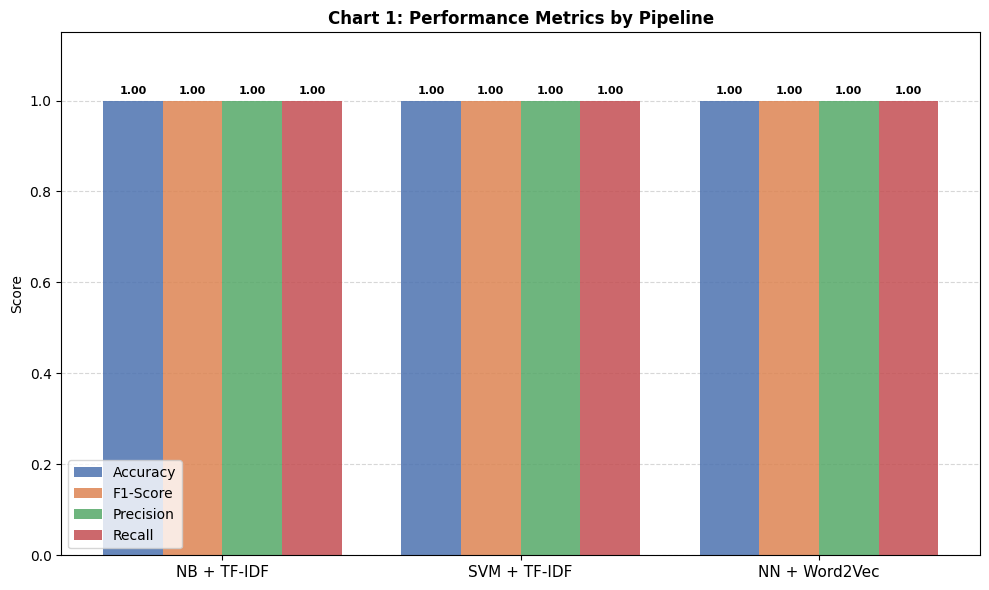

Chart 1 done: Performance Metrics


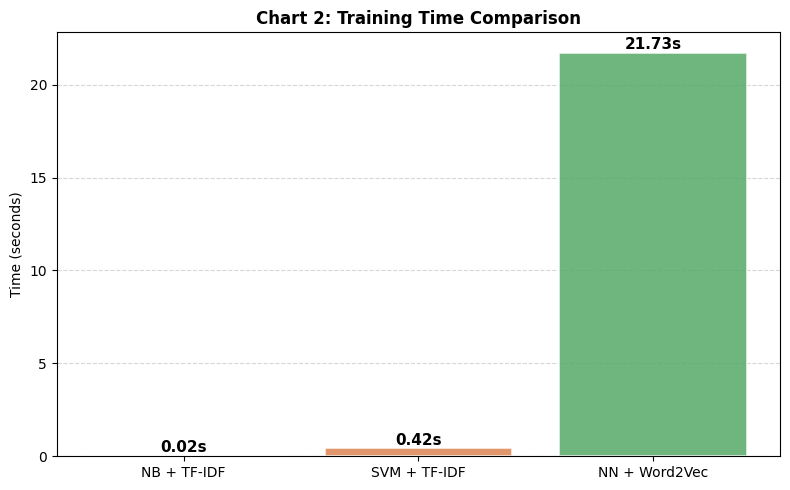

Chart 2 done: Training Time


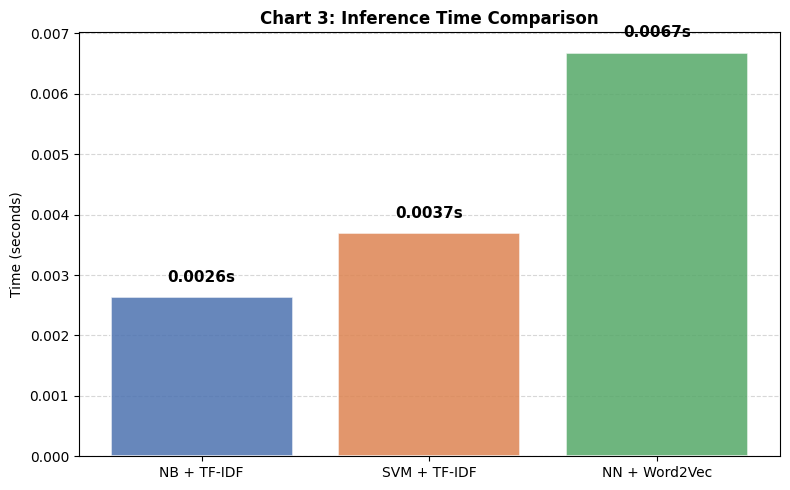

Chart 3 done: Inference Time


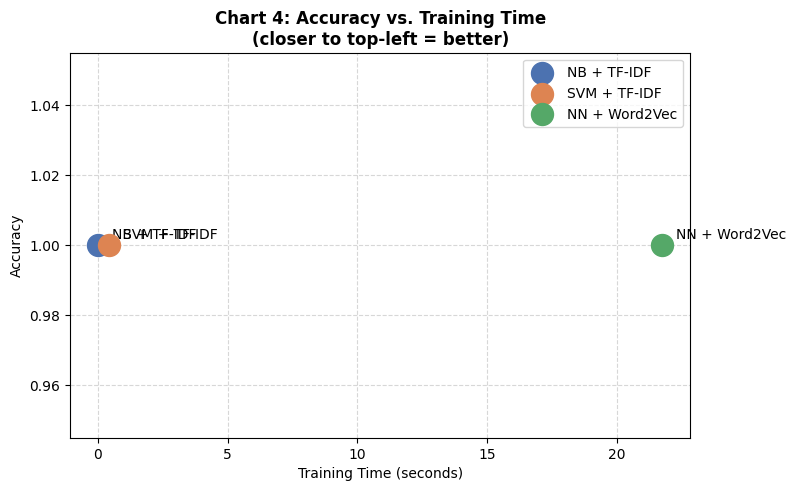

In [24]:
print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

pipelines   = ["NB + TF-IDF", "SVM + TF-IDF", "NN + Word2Vec"]
colors      = ["#4C72B0", "#DD8452", "#55A868"]
accuracies  = [nb_acc,  svm_acc,  nn_acc]
f1_scores   = [nb_f1,   svm_f1,   nn_f1]
precisions  = [nb_prec, svm_prec, nn_prec]
recalls     = [nb_rec,  svm_rec,  nn_rec]
train_times = [nb_train_time, svm_train_time, nn_train_time]
infer_times = [nb_infer_time, svm_infer_time, nn_infer_time]

# ── Chart 1: Performance Metrics ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(pipelines))
w = 0.2
metric_data   = [accuracies, f1_scores, precisions, recalls]
metric_labels = ["Accuracy", "F1-Score", "Precision", "Recall"]
metric_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for i, (m, lbl, c) in enumerate(zip(metric_data, metric_labels, metric_colors)):
    bars = ax.bar(x + i * w, m, width=w, label=lbl, color=c, alpha=0.85)
    for bar, val in zip(bars, m):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(pipelines, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Chart 1: Performance Metrics by Pipeline", fontweight="bold")
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("/content/chart1_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 done: Performance Metrics")

# ── Chart 2: Training Time ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(pipelines, train_times, color=colors, alpha=0.85, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, train_times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val:.2f}s", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_ylabel("Time (seconds)")
ax.set_title("Chart 2: Training Time Comparison", fontweight="bold")
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("/content/chart2_train_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 done: Training Time")

# ── Chart 3: Inference Time ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(pipelines, infer_times, color=colors, alpha=0.85, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, infer_times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0002,
            f"{val:.4f}s", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_ylabel("Time (seconds)")
ax.set_title("Chart 3: Inference Time Comparison", fontweight="bold")
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("/content/chart3_infer_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 done: Inference Time")

# ── Chart 4: Accuracy vs Training Time Scatter ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for pipeline, acc, tt, c in zip(pipelines, accuracies, train_times, colors):
    ax.scatter(tt, acc, s=250, color=c, zorder=5, label=pipeline)
    ax.annotate(pipeline, (tt, acc), textcoords="offset points", xytext=(10, 5), fontsize=10)
ax.set_xlabel("Training Time (seconds)")
ax.set_ylabel("Accuracy")
ax.set_title("Chart 4: Accuracy vs. Training Time\n(closer to top-left = better)", fontweight="bold")
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend()